EDA FOR CREDIT RISK MODELING
Please upload your xente_transactions.csv file


Saving xente_transactions.csv to xente_transactions.csv

 Loaded 95,662 rows, 16 columns
Columns: ['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'Amount', 'Value', 'TransactionStartTime', 'PricingStrategy', 'FraudResult']

=== DATA TYPES ===
TransactionId            object
BatchId                  object
AccountId                object
SubscriptionId           object
CustomerId               object
CurrencyCode             object
CountryCode               int64
ProviderId               object
ProductId                object
ProductCategory          object
ChannelId                object
Amount                  float64
Value                     int64
TransactionStartTime     object
PricingStrategy           int64
FraudResult               int64
dtype: object

=== MISSING VALUES ===
Series([], dtype: int64)
No missing values found!

=== NUMERICAL STATISTICS ===
       Coun

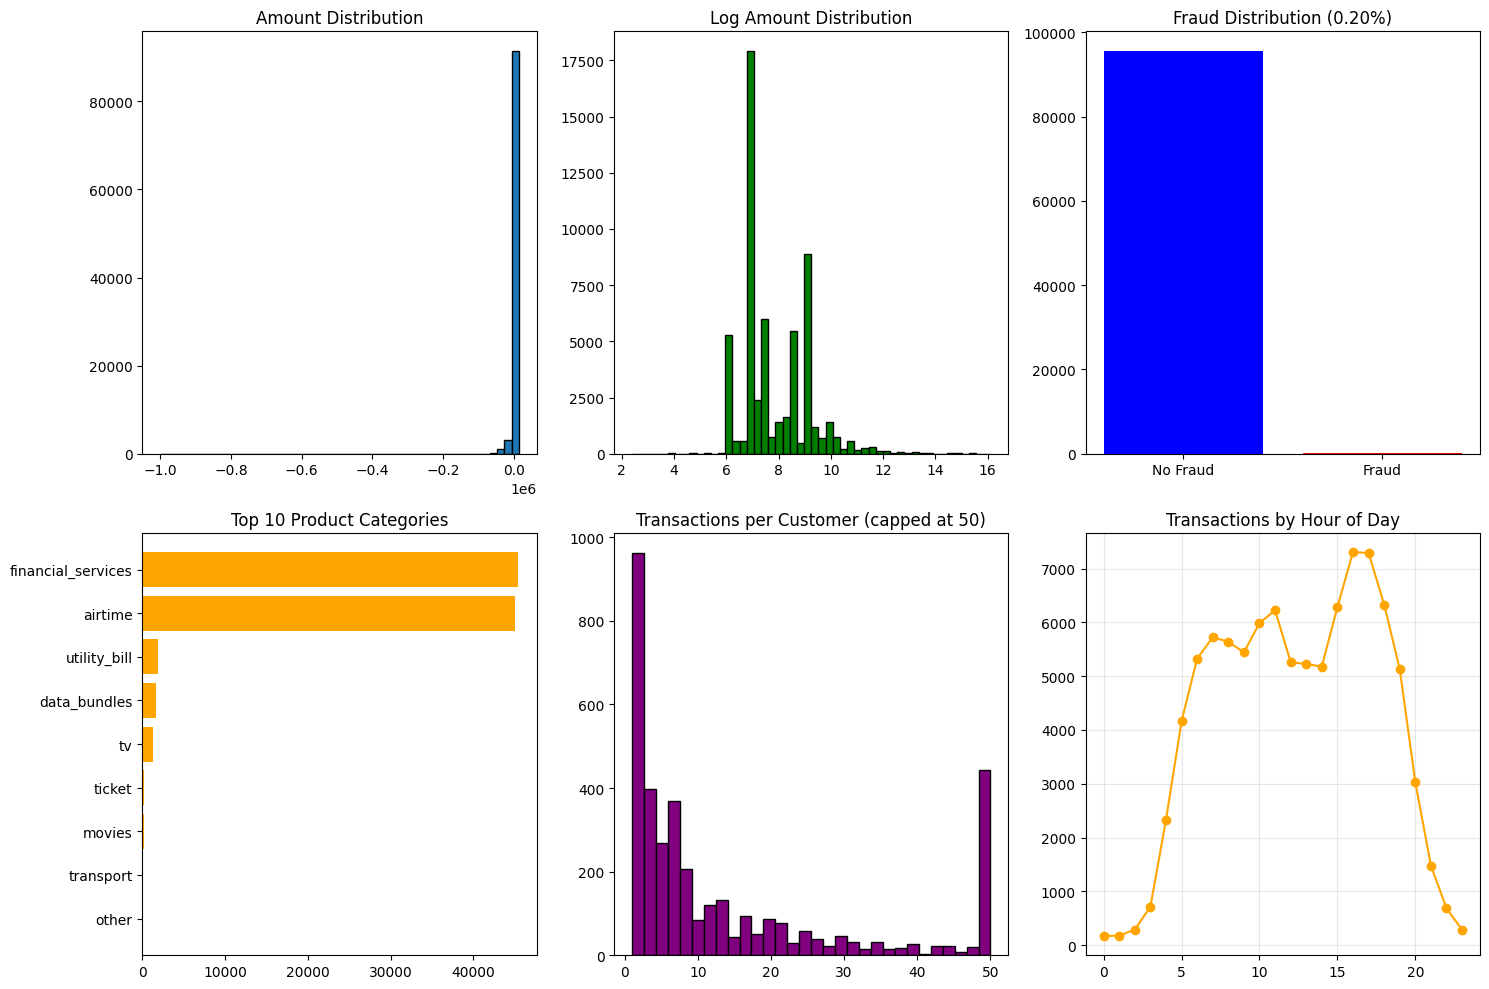


=== CORRELATION ANALYSIS ===
              Amount  FraudResult
Amount       1.00000      0.55737
FraudResult  0.55737      1.00000

TOP 5 KEY INSIGHTS
1. Amounts are highly skewed - use log transformation
2. Fraud is imbalanced - use F1 score, precision, recall
3. Top product categories dominate - encode top categories only
4. Customer activity varies widely - create RFM features
5. No default labels - use RFM + K-Means clustering for proxy target

EDA COMPLETE!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("EDA FOR CREDIT RISK MODELING")
print("=" * 60)

print("Please upload your xente_transactions.csv file")
uploaded = files.upload()

# Get the uploaded filename
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f"\n Loaded {len(df):,} rows, {len(df.columns)} columns")
print(f"Columns: {df.columns.tolist()}")
df.head()

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
print(missing[missing > 0])
if len(missing[missing > 0]) == 0:
    print("No missing values found!")

print("\n=== NUMERICAL STATISTICS ===")
print(df.describe())

print("\n=== AMOUNT STATISTICS ===")
print(f"Mean: ${df['Amount'].mean():.2f}")
print(f"Median: ${df['Amount'].median():.2f}")
print(f"Skewness: {df['Amount'].skew():.2f}")

# Create all plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0,0].hist(df['Amount'].clip(upper=df['Amount'].quantile(0.95)), bins=50, edgecolor='black')
axes[0,0].set_title('Amount Distribution')

axes[0,1].hist(np.log1p(df['Amount']), bins=50, edgecolor='black', color='green')
axes[0,1].set_title('Log Amount Distribution')

fraud_counts = df['FraudResult'].value_counts()
axes[0,2].bar(['No Fraud', 'Fraud'], fraud_counts.values, color=['blue', 'red'])
axes[0,2].set_title(f'Fraud Distribution ({df["FraudResult"].mean()*100:.2f}%)')

top_cats = df['ProductCategory'].value_counts().head(10)
axes[1,0].barh(range(len(top_cats)), top_cats.values, color='orange')
axes[1,0].set_yticks(range(len(top_cats)))
axes[1,0].set_yticklabels(top_cats.index)
axes[1,0].set_title('Top 10 Product Categories')
axes[1,0].invert_yaxis()

customer_txn = df.groupby('CustomerId')['TransactionId'].count()
axes[1,1].hist(customer_txn.clip(upper=50), bins=30, edgecolor='black', color='purple')
axes[1,1].set_title('Transactions per Customer (capped at 50)')

df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])
df['Hour'] = df['TransactionStartTime'].dt.hour
hourly = df['Hour'].value_counts().sort_index()
axes[1,2].plot(hourly.index, hourly.values, marker='o', color='orange')
axes[1,2].set_title('Transactions by Hour of Day')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()

print("\n=== CORRELATION ANALYSIS ===")
print(df[['Amount', 'FraudResult']].corr())

print("\n" + "=" * 60)
print("TOP 5 KEY INSIGHTS")
print("=" * 60)
print("1. Amounts are highly skewed - use log transformation")
print("2. Fraud is imbalanced - use F1 score, precision, recall")
print("3. Top product categories dominate - encode top categories only")
print("4. Customer activity varies widely - create RFM features")
print("5. No default labels - use RFM + K-Means clustering for proxy target")

print("\n" + "=" * 60)
print("EDA COMPLETE!")
print("=" * 60)

# Download the plot
from google.colab import files
files.download('eda_plots.png')